In [152]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt

# Exercise 1: Monte-Carlo

In [153]:
N = 10000

X= np.random.uniform(-1, 1, size=(N, 2))

In [154]:
X_in = X[np.linalg.norm(X, axis=1) <= 1]

X_out = X[np.linalg.norm(X, axis=1) > 1]

X_eq = X[np.linalg.norm(X, axis=1, ord=1) <= 1]

X_in.shape, X_out.shape, X_eq.shape

((7855, 2), (2145, 2), (5049, 2))

In [155]:
(X_in.shape[0] / N) * 4

3.142

In [156]:
X_in.shape[0] / (X_out.shape[0])

3.662004662004662

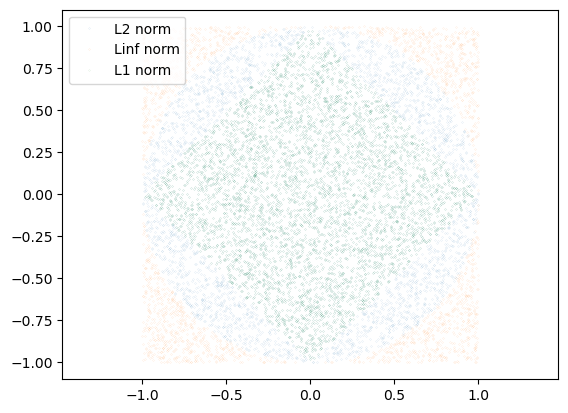

In [157]:
plt.axis('equal')

plt.plot(X_in[:,0], X_in[:,1], '.', markersize=0.1, label="L2 norm")
plt.plot(X_out[:,0], X_out[:,1], '.', markersize=0.1, label="Linf norm")
plt.plot(X_eq[:,0], X_eq[:,1], '.', markersize=0.1, label="L1 norm")

plt.legend()

plt.show()

In [158]:
print(X_eq.shape[0] / X_in.shape[0])

print(X_in.shape[0] / N)

# print(np.sqrt(2) / 2)

# print(np.pi / 6)

0.6427753023551878
0.7855


In [159]:
N = 1000

X_trials = np.array(range(1, N))

Y_trials_abs = np.array([], dtype=np.float128)
Y_trials_rel = np.array([], dtype=np.float128)

for i in range(1, N):
    X_trunc = X[:i]
    # X_trunc= np.random.uniform(-1, 1, size=(i, 2))
    
    # print(X_trunc.shape)
    
    X_in = X_trunc[np.linalg.norm(X_trunc, axis=1) <= 1]
    est_pi = np.float128((X_in.shape[0] / i) * 4)
    
    abs_err = np.abs(np.pi - est_pi)
    rel_err = abs_err / np.abs(np.pi)
    
    Y_trials_abs = np.append(Y_trials_abs, [abs_err])
    Y_trials_rel = np.append(Y_trials_rel, [rel_err])


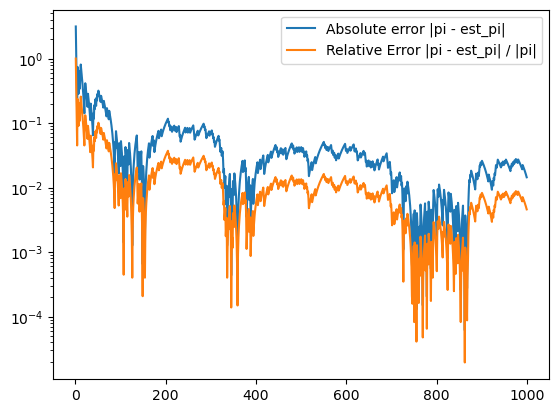

In [160]:
plt.plot(X_trials, Y_trials_abs, 'o-', markersize=0.01, label="Absolute error |pi - est_pi|")

plt.plot(X_trials, Y_trials_rel, 'o-', markersize=0.01, label="Relative Error |pi - est_pi| / |pi|")

plt.yscale('log', base=10)

plt.legend()

plt.show()

# Exercise 2: Mandelbrot set

In [161]:
# z0 = c
#zn+1 = zn**2 + c

# z0 = 3.0 + 1j*4.0
# print(np.real(z0), np.imag(z0))

x = np.linspace(-2, 1, 300)
y = np.linspace(-1.5, 1.5, 300)

In [162]:
# x[:, np.newaxis].shape
# # Creates a 300x1 "matrix" / vector in that case (1 big array of 300 1-array)

In [163]:
# y[np.newaxis, :]
# # "Transpose" of above, so one array made of one 300-array

In [164]:
c = x[:, np.newaxis] + 1j*y[np.newaxis, :]

c.shape

(300, 300)

In [165]:
np.zeros_like(c)

array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],
      shape=(300, 300))

In [166]:
N = 100

z = np.zeros_like(c)
for _ in range(0,N):
    z = z**2 + c
    
# z
# becomes nan because of overflows

/tmp/ipykernel_62506/768839083.py:5: RuntimeWarning: overflow encountered in square
  z = z**2 + c
/tmp/ipykernel_62506/768839083.py:5: RuntimeWarning: invalid value encountered in square
  z = z**2 + c


In [167]:
bound = 100.0
mandelbrot_set = np.abs(z) < bound
np.count_nonzero(mandelbrot_set)

np.int64(15426)

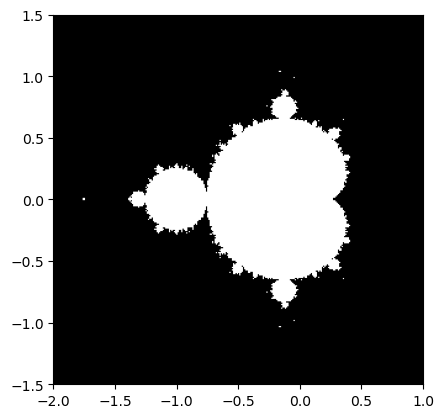

In [ ]:
plt.imshow(mandelbrot_set.T, extent=[-2, 1, -1.5, 1.5])
plt.gray()

plt.show()

##### 